In [1]:
import numpy as np
import pandas as pd
import cartopy.io.shapereader as shpreader
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
from cartopy.feature import ShapelyFeature
import cartopy.io.img_tiles as cimgt
import netCDF4 as nc
import xarray as xr
from scipy.spatial import ConvexHull
from matplotlib.patches import Polygon
import matplotlib.patches as mpatches
import shapely
import geopandas as gpd
from tqdm import tqdm
import matplotlib.gridspec as gridspec
import datetime, glob
import matplotlib as mpl
from matplotlib.lines import Line2D
from shapely import Polygon, Point
import yaml
import matplotlib.colors as mcolors
from matplotlib import ticker
import matplotlib.dates as mdates
from scipy.stats import pearsonr
import sklearn.metrics as metrics
from matplotlib.colors import LinearSegmentedColormap
from cartopy.io.img_tiles import GoogleTiles

# Loading config files

In [2]:
class TROPOMI_config():
    def __init__(self, cfs):
        self.tropomi_filepath = cfs["tropomi_filepath"]
        self.tropomi_train_file = cfs["tropomi_train_file"]
        self.tropomi_test_file = cfs["tropomi_test_file"]
        self.bkg_file = cfs["tropomi_bkg_file"]
        
        self.start_time = datetime.datetime.strptime(cfs["start_time"], "%Y%m%d%H")
        self.end_time = datetime.datetime.strptime(cfs["end_time"], "%Y%m%d%H")

        self.week_start_date = self.start_time - datetime.timedelta(days=self.start_time.weekday() + 1 if self.start_time.weekday() < 6 else 0) - datetime.timedelta(hours=self.start_time.hour)
        self.inv_start_time = self.week_start_date - datetime.timedelta(days=14)
        
        self.week_end_date = self.end_time - datetime.timedelta(days=self.end_time.weekday() + 1 if self.end_time.weekday() < 6 else 0) - datetime.timedelta(hours=self.end_time.hour)
        self.inv_end_time = self.week_end_date + datetime.timedelta(days=14) # datetime.datetime(2021, 1, 2, 23)
    
        self.xres = cfs["xres"]
        self.yres = cfs["yres"]
        self.clon = cfs["clon"]
        self.clat = cfs["clat"]
        
        # self.lons = np.arange(self.clon-200*self.xres, self.clon+200*self.xres+0.001, self.xres)[:-1]
        # self.lats = np.arange(self.clat-200*self.xres, self.clat+200*self.xres+0.001, self.xres)[:-1]
        data = np.load(cfs["lat_lon_file"])
        self.lons = data["lon"]
        self.lats = data["lat"]
    
        self.upwind_degree_margin = cfs["upwind_degree_margin"]
        self.upwind_date_margin = cfs["upwind_date_margin"]
        self.obs_indices_margin = cfs["obs_indices_margin"]
        self.met_temp_resolution_background = cfs["met_temp_resolution_background"] # hours wind data for computing background 

        self.hr3latlon_mapping = cfs["HRRR_LAT_LON_MAPPING"]
        self.hr3lon_full = np.load(self.hr3latlon_mapping)['lon']
        self.hr3lat_full = np.load(self.hr3latlon_mapping)['lat']
        self.hr3lon_full = (self.hr3lon_full+180)%360-180  # convert from 0~360 to -180~180
        self.HRRR_DIR = cfs["HRRR_DIR"]
        self.trimsize = cfs["trimsize"]
    
        self.model_path = cfs["model_path"]
        self.footprint_path = cfs["footprint_path"]
        self.maximum_domain_trajectory = cfs["maximum_domain_trajectory"]

        self.inventory_type = cfs["inventory_type"]
        self.inventory_path = cfs["inventory_path"]
        self.ems_uncert = cfs["ems_uncert"]

class Arguments():
    def __init__(self, config_file):
        self.config = config_file
        self.start_time = "2018050100"
        self.end_time = "2026010623"

args1 = Arguments("config_Delaware.yaml")

with open(args1.config, "r") as f:
    cfg = yaml.safe_load(f)
    cfg["start_time"] = args1.start_time
    cfg["end_time"] = args1.end_time

config1 = TROPOMI_config(cfg)

args2 = Arguments("config_Midland.yaml")
with open(args2.config, "r") as f:
    cfg = yaml.safe_load(f)
    cfg["start_time"] = args2.start_time
    cfg["end_time"] = args2.end_time

config2 = TROPOMI_config(cfg)

# Loading EPA emissions

In [3]:
from emissions import getEmissions

dates = pd.date_range(start=config1.inv_start_time, end=config1.inv_end_time, freq="W")

m = config1.lons.shape[0]*config1.lats.shape[0]
inventory_type = "EPA"
inventory_path = "Express_Extension_Gridded_GHGI_Methane_v2_2020.nc" # (can be obtained from https://zenodo.org/records/8367082; last access: 14 May 2026)

# Delaware domain emissions
emission1 = getEmissions(config1.lons, config1.lats, inventory_type, m, inventory_path=inventory_path)
# Midland domain emissions
emission2 = getEmissions(config2.lons, config2.lats, inventory_type, m, inventory_path=inventory_path)

Inventory type: EPA | Ems scaling factor: 1


/home/disk/p/nd349/miniconda3/lib/python3.13/site-packages/xarray/backends/plugins.py:109: RuntimeWarning: Engine 'pseudonetcdf' loading failed:
module 'unittest' has no attribute 'makeSuite'
  external_backend_entrypoints = backends_dict_from_pkg(entrypoints_unique)


Inventory type: EPA | Ems scaling factor: 1


In [4]:
# Creating latitude and longitude arrays over whole Permian Basin

yres = config1.lats[1]-config1.lats[0]
xres = config1.lons[1]-config1.lons[0]

big_lats = np.arange(config1.lats[0] - 300*yres, config1.lats[-1] + 300*yres, yres)
big_lons = np.arange(config1.lons[0] - 200*xres, config1.lons[-1] + 400*xres, xres)
big_lats.shape, big_lons.shape

((1000,), (999,))

# Loading Delaware Posterior Emissions

In [5]:
uncert = 0.5

inventory_type = "EPA"
files = glob.glob(f"fluxes/Delaware/*.nc")
files.sort()

print(len(files))

flux_dict = {}
actual_obs_train = []
actual_obs_test = []
prior_obs_train = []
prior_obs_test = []
post_obs_train = []
post_obs_test = []
for file in files:
    data = nc.Dataset(file)
    timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
    fluxes = np.array(data["post_fluxes"])
    actual_obs_train += list(np.array(data["y_actual_train"]))
    prior_obs_train += list(np.array(data["ysim_prior_train"]))
    post_obs_train += list(np.array(data["ysim_pred_train"]))

    actual_obs_test += list(np.array(data["y_actual_test"]))
    prior_obs_test += list(np.array(data["ysim_prior_test"]))
    post_obs_test += list(np.array(data["ysim_pred_test"]))
    for idx, timestamp in enumerate(timestamps):
        if 2 <= idx <= len(timestamps) - 3:
            flux_dict[timestamp] = flux_dict.get(timestamp, []) + [fluxes[idx]]
    data.close()
    
kg_km2_hr_conversion_factor = 3600*16/1000 # conversion to km/km2/hr
res_flux_dict = {}
for key, value in flux_dict.items():
    res_flux_dict[key] = np.average(np.array(value), axis=0)*kg_km2_hr_conversion_factor
fluxes = np.array(list(res_flux_dict.values()))
fluxes = fluxes * 365.25*24/1e3 # Mg/km2/year
fluxes1 = fluxes.copy()
ems1 = np.average(fluxes, axis=0)


92


/tmp/ipykernel_4141143/2648428134.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
/tmp/ipykernel_4141143/2648428134.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fluxes = np.array(data["post_fluxes"])
/tmp/ipykernel_4141143/2648428134.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must 

# Loading Midland Posterior Emissions

In [6]:
uncert = 0.5
inventory_type = "EPA"
files = glob.glob(f"fluxes/Midland/*.nc")
files.sort()

print(len(files))

flux_dict = {}
actual_obs_train = []
actual_obs_test = []
prior_obs_train = []
prior_obs_test = []
post_obs_train = []
post_obs_test = []
for file in files:
    data = nc.Dataset(file)
    timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
    fluxes = np.array(data["post_fluxes"])
    actual_obs_train += list(np.array(data["y_actual_train"]))
    prior_obs_train += list(np.array(data["ysim_prior_train"]))
    post_obs_train += list(np.array(data["ysim_pred_train"]))

    actual_obs_test += list(np.array(data["y_actual_test"]))
    prior_obs_test += list(np.array(data["ysim_prior_test"]))
    post_obs_test += list(np.array(data["ysim_pred_test"]))
    for idx, timestamp in enumerate(timestamps):
        if 2 <= idx <= len(timestamps) - 3:
            flux_dict[timestamp] = flux_dict.get(timestamp, []) + [fluxes[idx]]
    data.close()
    
kg_km2_hr_conversion_factor = 3600*16/1000 # conversion to kg/km2/hr
res_flux_dict = {}
for key, value in flux_dict.items():
    res_flux_dict[key] = np.average(np.array(value), axis=0)*kg_km2_hr_conversion_factor
fluxes = np.array(list(res_flux_dict.values()))
fluxes = fluxes * 365.25*24/1e3 # Mg/km2/year
fluxes2 = fluxes.copy()
ems2 = np.average(fluxes, axis=0)

92


/tmp/ipykernel_4141143/161432917.py:17: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
/tmp/ipykernel_4141143/161432917.py:18: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fluxes = np.array(data["post_fluxes"])
/tmp/ipykernel_4141143/161432917.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must imp

# Creating mask for merging emissions

In [7]:
delaware_mask = np.zeros((big_lats.shape[0], big_lons.shape[0]))
midland_mask = np.zeros((big_lats.shape[0], big_lons.shape[0]))
delaware_mask[300:700, 200:600] = 1
midland_mask[203:603,446:846] = 1
delaware_mask[300:603, 446:600] = 0
midland_mask[300:603, 446:600] = 0


# Example: grid indices

# Two points (row, col format)
p1 = (300, 540)
p2 = (603, 490)
r1, c1 = p1   # point A
r2, c2 = p2   # point B
# convert to lat/lon
lat1, lon1 = big_lats[r1], big_lons[c1]
lat2, lon2 = big_lats[r2], big_lons[c2]
lon_grid, lat_grid = np.meshgrid(big_lons[446:600], big_lats[300:603])  
val = (lon_grid - lon1) * (lat2 - lat1) - \
      (lat_grid - lat1) * (lon2 - lon1)

m_mask  = val >= 0
d_mask = val < 0
line_mask  = np.isclose(val, 0)
delaware_mask[300:603, 446:600] += d_mask
midland_mask[300:603, 446:600] += m_mask

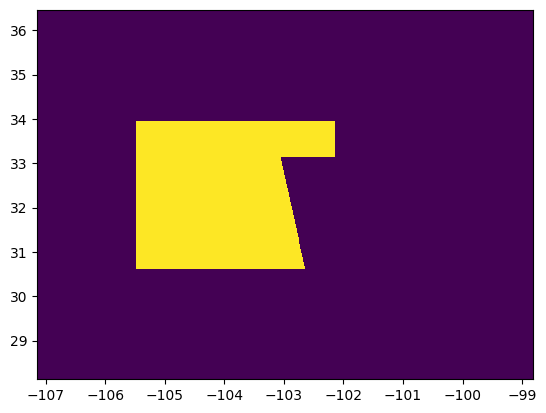

In [8]:
plt.pcolor(big_lons, big_lats, delaware_mask)

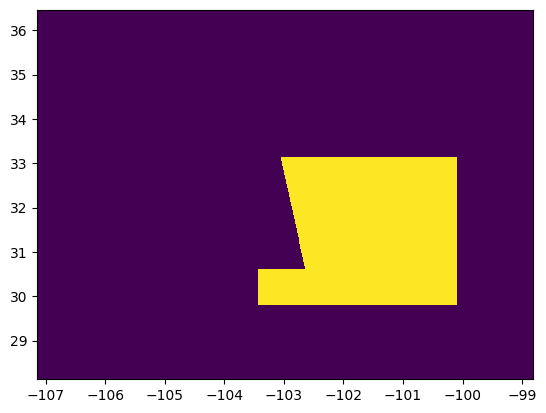

In [9]:
plt.pcolor(big_lons, big_lats, midland_mask)

# Merging emissions

In [10]:
post_mean = np.zeros((big_lats.shape[0], big_lons.shape[0]))
post_mean[300:700, 200:600] += np.multiply(ems1, delaware_mask[300:700, 200:600])
post_mean[203:603,446:846] += np.multiply(ems2, midland_mask[203:603,446:846])
post_mean[post_mean==0] = np.nan

In [11]:
prior_ems = np.zeros((2, big_lats.shape[0], big_lons.shape[0]))
prior_ems[0, 300:700, 200:600] = emission1.emissions
prior_ems[1, 203:603,446:846] = emission2.emissions
prior_ems[prior_ems==0] = np.nan
prior_mean = np.nanmean(prior_ems, axis=0)[100:-99, 100:-99]
prior_mean *= kg_km2_hr_conversion_factor
prior_mean *= 365.25*24/1e3 # Mg/km2/year
prior_mean[200:600, 100:500][np.isnan(prior_mean[200:600, 100:500])] = 0

/tmp/ipykernel_4141143/3046721480.py:5: RuntimeWarning: Mean of empty slice
  prior_mean = np.nanmean(prior_ems, axis=0)[100:-99, 100:-99]


# Loading infrastructure data

In [12]:
# Pipelines (botained from OGIM dataset)

filtered_pipelines = gpd.read_file("data/major_gas_pipelines.csv")
geometry_series = gpd.GeoSeries.from_wkt(filtered_pipelines['geometry'])

filtered_pipelines = gpd.GeoDataFrame(filtered_pipelines, geometry=geometry_series, crs="EPSG:4326")
filtered_pipelines

,OGIM_ID,CATEGORY,REGION,COUNTRY,STATE_PROV,SRC_REF_ID,SRC_DATE,ON_OFFSHORE,FAC_NAME,FAC_ID,...,INSTALL_DATE,COMMODITY,LIQ_CAPACITY_BPD,LIQ_THROUGHPUT_BPD,GAS_CAPACITY_MMCFD,GAS_THROUGHPUT_MMCFD,PIPE_DIAMETER_MM,PIPE_LENGTH_KM,PIPE_MATERIAL,geometry
0,1585434,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,197,2025-01-29,ONSHORE,GCX,5316710,...,1900-01-01,"NATURAL GAS, TRANSMISSION",-999.0,-999.0,-999.0,-999.0,1070.0,2.03,N/A,"LINESTRING (-101.58439 31.07924, -101.58426 31..."
1,1581839,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,197,2025-01-29,ONSHORE,BLACKCOMB PIPELINE,5604748,...,1900-01-01,"NATURAL GAS, TRANSMISSION",-999.0,-999.0,-999.0,-999.0,1070.0,0.0234,N/A,"LINESTRING (-101.58484 31.07941, -101.58463 31..."
2,1585435,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,197,2025-01-29,ONSHORE,GCX,5316711,...,1900-01-01,"NATURAL GAS, TRANSMISSION",-999.0,-999.0,-999.0,-999.0,1070.0,0.0234,N/A,"LINESTRING (-101.5846 31.07941, -101.58451 31...."
3,1586248,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,197,2025-01-29,ONSHORE,WHISTLER PIPELINE,5722789,...,1900-01-01,"NATURAL GAS, TRANSMISSION",-999.0,-999.0,-999.0,-999.0,1070.0,0.0234,N/A,"LINESTRING (-101.58484 31.07941, -101.58463 31..."
4,1867222,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,TEXAS,197,2025-01-29,ONSHORE,PHP,5300203,...,1900-01-01,"NATURAL GAS, TRANSMISSION",-999.0,-999.0,-999.0,-999.0,1070.0,0.0219,N/A,"LINESTRING (-101.56763 31.1192, -101.56749 31...."
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1462,1512486,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,NEW MEXICO,96,2020-10-21,ONSHORE,N/A,21682,...,1900-01-01,NATURAL GAS,-999.0,-999.0,-999.0,-999.0,-999.0,0.000633,N/A,"LINESTRING (-104.44878 33.29407, -104.44878 33..."
1463,1512487,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,NEW MEXICO,96,2020-10-21,ONSHORE,N/A,21683,...,1900-01-01,NATURAL GAS,-999.0,-999.0,-999.0,-999.0,-999.0,1.24,N/A,"LINESTRING (-104.43864 33.28871, -104.43874 33..."
1464,1510934,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,NEW MEXICO,96,2020-10-21,ONSHORE,N/A,20113,...,1900-01-01,NATURAL GAS,-999.0,-999.0,-999.0,-999.0,-999.0,1.06,N/A,"LINESTRING (-103.31602 32.61342, -103.31577 32..."
1465,1512488,OIL AND NATURAL GAS PIPELINES,NORTH AMERICA,UNITED STATES OF AMERICA,NEW MEXICO,96,2020-10-21,ONSHORE,N/A,21684,...,1900-01-01,NATURAL GAS,-999.0,-999.0,-999.0,-999.0,-999.0,0.701,N/A,"LINESTRING (-104.44144 33.28968, -104.44301 33..."


In [13]:
# Wells (obtained from Texas Railroad Commission and new mexico Petroleum Recovery Research Center

wells = np.load("data/oil_and_gas_wells.npz")
oil_wells = wells["oil_wells"]
gas_wells = wells["gas_wells"]

In [14]:
# Midstream infrastructures obtained from Cusworth et al., 2021 (Intermittency of Large Methane Emitters in the Permian Basin)
data = pd.read_excel("data/cusworth_et_al_2021_sources.xlsx", sheet_name="permian_source_list_EST_0305202")
data = data[data["Qsource (kg/hr): Persistence adjusted average source emissions"]>200].reset_index(drop=True)

categories = set(data["Source type (best estimate)"])
compressor_list = data[data["Source type (best estimate)"]=="compressor"].reset_index(drop=True)
pipeline_list = data[data["Source type (best estimate)"]=="pipeline"].reset_index(drop=True)
processing_list = data[data["Source type (best estimate)"]=="processing"].reset_index(drop=True)
tank_list = data[data["Source type (best estimate)"]=="tank"].reset_index(drop=True)
well_list = data[data["Source type (best estimate)"]=="well"].reset_index(drop=True)

data

,Source identifier,Source latitude (deg),Source longitude (deg),Source type (best estimate),IPCC sector,Number overflights,Source Persistence (f),Confidence in persistence,Qsource (kg/hr): Persistence adjusted average source emissions,Sigma Qsource (kg/hr): Uncertainty for persistence adjusted average source emissions
0,P00001,32.212086,-103.697212,tank,1B2 Oil & Natural Gas,12,0.833333,0.968324,865.484230,307.380288
1,P00002,32.199937,-103.673324,tank,1B2 Oil & Natural Gas,12,0.333333,0.968324,207.089504,47.441634
2,P00003,32.116135,-103.626582,tank,1B2 Oil & Natural Gas,12,0.583333,0.968324,305.700650,97.254972
3,P00006,32.998981,-102.812484,processing,1B2 Oil & Natural Gas,5,0.800000,0.762695,1410.479729,642.123719
4,P00007,32.027791,-103.570765,compressor,1B2 Oil & Natural Gas,14,0.785714,0.982182,582.025749,147.359172
...,...,...,...,...,...,...,...,...,...,...
618,P01788,32.863035,-104.037690,compressor,1B2 Oil & Natural Gas,1,1.000000,0.250000,310.762002,54.989954
619,P01790,32.894470,-104.018010,pipeline,1B2 Oil & Natural Gas,1,1.000000,0.250000,225.749648,85.643310
620,P01791,32.817815,-104.156670,tank,1B2 Oil & Natural Gas,1,1.000000,0.250000,461.334046,278.558786
621,P01792,32.809964,-104.161130,pipeline,1B2 Oil & Natural Gas,1,1.000000,0.250000,207.128334,120.692229


# Visualizing emissions

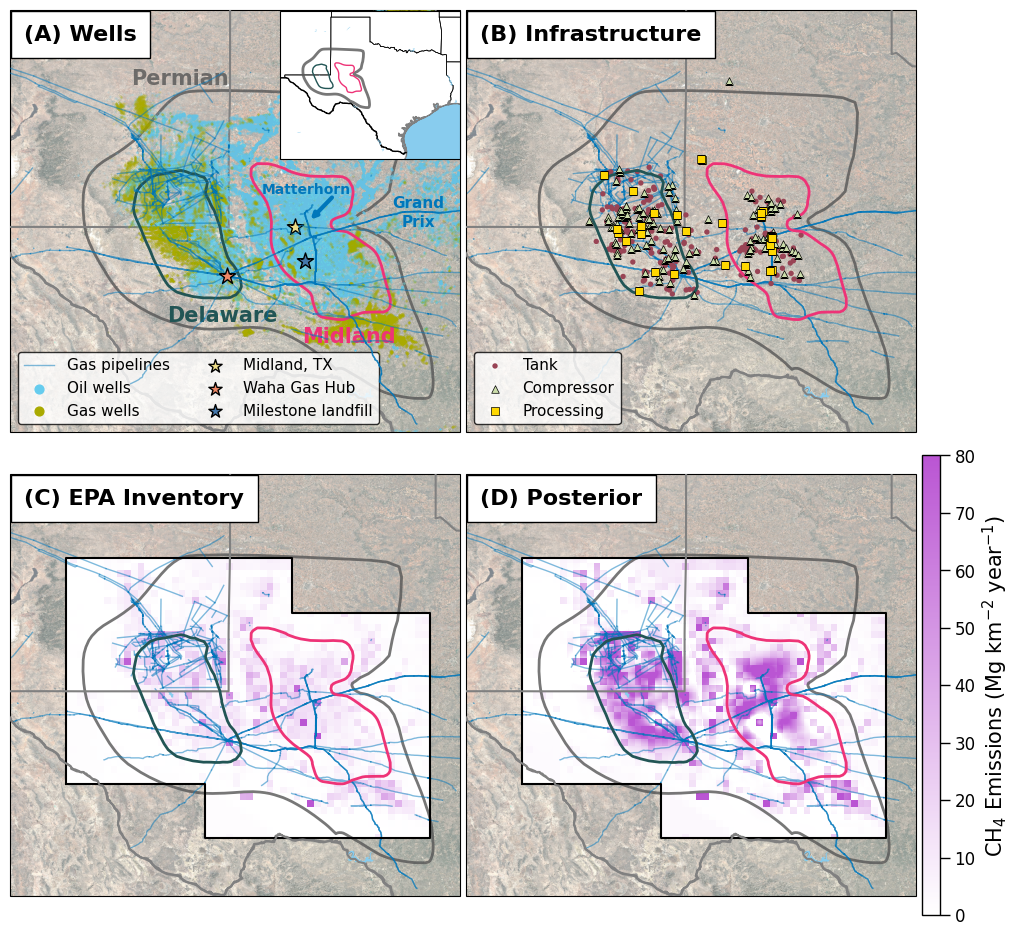

In [15]:
cmap1 = mpl.colors.LinearSegmentedColormap.from_list("custom", ["white", "mediumorchid"])

fig = plt.figure(figsize=(12, 12))

gs = gridspec.GridSpec(
    2, 3,
    width_ratios=[1, 1, 0.04],  # last column for colorbar
    height_ratios=[1, 1],  # last column for colorbar
    wspace=0.02,
    hspace=0.01
)

ax1 = fig.add_subplot(gs[1, 0], projection=ccrs.PlateCarree())
ax2 = fig.add_subplot(gs[0, 0], projection=ccrs.PlateCarree())
ax3 = fig.add_subplot(gs[1, 1], projection=ccrs.PlateCarree())
ax4 = fig.add_subplot(gs[0, 1], projection=ccrs.PlateCarree())
cax = fig.add_subplot(gs[1, 2])  # colorbar axis spanning both rows

tiler = GoogleTiles(style='satellite')

# -------------------------
# Set extent
# -------------------------
extent = (
    big_lons[100], big_lons[-100],
    big_lats[100], big_lats[-150]
)

for ax in [ax1, ax2, ax3, ax4]:
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    # Coastlines & borders
    ax.coastlines(resolution='10m', linewidth=1, color='grey')
    ax.add_feature(cfeature.BORDERS, linewidth=1.5, edgecolor='grey')
    ax.add_feature(cfeature.LAKES, facecolor='#88CCEE')
    ax.add_feature(cfeature.OCEAN, facecolor='#88CCEE')
    
ax1.add_image(tiler, 10, alpha=0.5)
ax3.add_image(tiler, 10, alpha=0.5)
ax2.add_image(tiler, 10, alpha=0.5)
ax4.add_image(tiler, 10, alpha=0.5)
# -------------------------
# Texas boundary
# -------------------------
states_shp = gpd.read_file("data/cb_2018_us_state_20m.zip")
texas_state = states_shp[states_shp["STATEFP"] == "48"]
texas_feature = ShapelyFeature(
    texas_state.geometry,
    ccrs.PlateCarree(),
    edgecolor="grey",
    facecolor="none",
    linewidth=1.5
)

ax1.add_feature(texas_feature, zorder=3)
ax2.add_feature(texas_feature, zorder=3)
ax3.add_feature(texas_feature, zorder=3)
ax4.add_feature(texas_feature, zorder=3)

pcm1 = ax1.pcolor(
    big_lons[100:-99],
    big_lats[100:-99],
    prior_mean,#[100:-99, 100:-99],
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=80,
    cmap=cmap1
)

pcm1 = ax3.pcolor(
    big_lons[100:-99],
    big_lats[100:-99],
    post_mean[100:-99, 100:-99],
    transform=ccrs.PlateCarree(),
    vmin=0,
    vmax=80,
    cmap=cmap1
)

m_pipes = filtered_pipelines.geometry.get_coordinates()
grouped = m_pipes.groupby(m_pipes.index)
label = 0
for idx, data in grouped:
    if label == 0:
        ax3.plot(data["x"], data["y"], linewidth=1, color='#0077BB')
        ax1.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5)
        ax2.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5, label="Gas pipelines", zorder=50)
        label += 1
    ax3.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5)
    ax1.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5)
    ax2.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5, zorder=150)


cbar1 = fig.colorbar(pcm1, cax=cax, orientation="vertical", pad=0.1, shrink=0.8)

cbar1.set_label("CH$_4$ Emissions (Mg km$^{-2}$ year$^{-1}$)",
                fontsize=15)
cbar1.ax.tick_params(length=7, width=1, labelsize=12)
cbar1.outline.set_linewidth(1)

# -------------------------
# Wells (bottom panel)
# -------------------------
ax2.scatter(
    [oil_wells[0][1]],
    [oil_wells[0][0]],
    s=0.1,
    zorder=30,
    color="#66CCEE",
    label="Oil wells",
    transform=ccrs.PlateCarree()
)

ax2.scatter(
    [gas_wells[0][1]],
    [gas_wells[0][0]],
    s=0.1,
    zorder=30,
    color="#AAAA00",
    label="Gas wells",
    transform=ccrs.PlateCarree()
)

ax2.scatter(
    [val[1] for val in oil_wells],
    [val[0] for val in oil_wells],
    s=0.1,
    zorder=30,
    alpha=0.25,
    color="#66CCEE",
    # label="Oil wells",
    transform=ccrs.PlateCarree()
)

ax2.scatter(
    [val[1] for val in gas_wells],
    [val[0] for val in gas_wells],
    s=0.1,
    zorder=30,
    alpha=0.25,
    color="#AAAA00",
    # label="Gas wells",
    transform=ccrs.PlateCarree()
)

# -------------------------
# Permian Basin
# -------------------------
permian = gpd.read_file("data/Permian/PermianBasin_Extent_201712.shp")

permian_feature = ShapelyFeature(
    permian.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    alpha=0.8,
    edgecolor='#555555',
    linewidth=2
)

ax1.add_feature(permian_feature)
ax2.add_feature(permian_feature)
ax3.add_feature(permian_feature)
ax4.add_feature(permian_feature)

# -------------------------
# Shale plays
# -------------------------
basins = gpd.read_file("data/shapefiles/ShalePlays_US_EIA_Dec2021.shp")

delaware = basins[
    basins['Shale_play'].isin(["Delaware"])
]

midland = basins[
    basins['Shale_play'].isin(["Wolfcamp - Midland"])
]

delaware = ShapelyFeature(
    delaware.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#225555',
    linewidth=2
)

ax1.add_feature(delaware, zorder=50)
ax2.add_feature(delaware, zorder=50)
ax3.add_feature(delaware, zorder=50)
ax4.add_feature(delaware, zorder=50)
midland = ShapelyFeature(
    midland.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#EE3377',
    linewidth=2
)
ax1.add_feature(midland, zorder=50)
ax2.add_feature(midland, zorder=50)
ax3.add_feature(midland, zorder=50)
ax4.add_feature(midland, zorder=50)

ax2.scatter([-102.0757], [31.9996], marker="*", edgecolor="k", s=0.25, label="Midland, TX", zorder=1, color="#EEDD88")
ax2.scatter([-102.0757], [31.9996], marker="*", edgecolor="k", s=150, zorder=100, color="#EEDD88")

ax2.scatter([-103.086], [31.271], marker="*", edgecolor="k", s=0.25, label="Waha Gas Hub", zorder=100, color="#EE8866")
ax2.scatter([-103.086], [31.271], marker="*", edgecolor="k", s=150, zorder=150, color="#EE8866")

ax2.scatter([-101.939953], [31.496023], marker="*", edgecolor="k", s=0.25, label="Milestone landfill", zorder=1, color="#4477AA")
ax2.scatter([-101.939953], [31.496023], marker="*", edgecolor="k", s=150, zorder=100, color="#4477AA")


# -------------------------
# Legend
# -------------------------
ax2.legend(loc="lower left", markerscale=20, edgecolor="black", ncol=2, fontsize=11)

m_pipes = filtered_pipelines.geometry.get_coordinates()
grouped = m_pipes.groupby(m_pipes.index)
label = 0
for idx, data in grouped:
    if label == 0:
        ax4.plot(data["x"], data["y"], linewidth=1, color='#0077BB')
        label += 1
    ax4.plot(data["x"], data["y"], color='#0077BB', linewidth=1, alpha=0.5)

ax4.scatter(
    tank_list["Source longitude (deg)"], 
    tank_list["Source latitude (deg)"], 
    label="Tank", 
    color="#994455", 
    s=15,             
    marker="o", 
    edgecolors='none', 
    zorder=30
)

# 2. Plot Compressors with a 'hollow' or 'thin' look
ax4.scatter(
    compressor_list["Source longitude (deg)"], 
    compressor_list["Source latitude (deg)"], 
    color="#CCDDAA", 
    label="Compressor", 
    marker='^', 
    edgecolor="k", 
    linewidth=0.5,     # Thin edges make it look sharper
    s=30,              # Slightly smaller
    zorder=50
)

# 3. Plot Processing Stations as the "Hero" elements
ax4.scatter(
    processing_list["Source longitude (deg)"], 
    processing_list["Source latitude (deg)"], 
    color="#FFD700",   # Gold stands out better than Grey (#DDDDDD) against basin colors
    label="Processing", 
    marker="s", 
    edgecolor="k",
    linewidth=0.5,
    s=30,             # Make these significantly larger
    zorder=100
)

ax4.legend(loc="lower left", edgecolor="black", ncol=1, fontsize=11)

bbox_props = dict(boxstyle="square,pad=0.6", ec="none", lw=1, facecolor='none', alpha=0)
ax2.text(0.27, 0.86, "Permian", transform=ax2.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#555555", zorder=50, alpha=0.8)
ax2.text(0.35, 0.3, "Delaware", transform=ax2.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#225555", zorder=50)
ax2.text(0.65, 0.25, "Midland", transform=ax2.transAxes,
            fontsize=15, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#EE3377", zorder=50)

ax2.text(0.85, 0.56, "Grand", transform=ax2.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#0077BB", zorder=150)
ax2.text(0.87, 0.515, "Prix", transform=ax2.transAxes,
            fontsize=11, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#0077BB", zorder=150)

ax2.text(0.56, 0.59, "Matterhorn", transform=ax2.transAxes,
            fontsize=10, fontweight='bold', va='top', ha='left', bbox=bbox_props, color="#0077BB", zorder=150)

bbox_props = dict(boxstyle="square,pad=0.6", ec="black", lw=1, facecolor='white', alpha=1)
ax2.text(0.032, 0.965, "(A) Wells", transform=ax2.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)
ax4.text(0.032, 0.965, "(B) Infrastructure", transform=ax4.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)
ax1.text(0.032, 0.965, "(C) EPA Inventory", transform=ax1.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)
ax3.text(0.032, 0.965, "(D) Posterior", transform=ax3.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)

posterior_boundary = [[big_lons[200], big_lats[300]], [big_lons[446], big_lats[300]], [big_lons[446], big_lats[203]], [big_lons[846], big_lats[203]], [big_lons[846], big_lats[603]], [big_lons[600], big_lats[603]], [big_lons[600], big_lats[700]], [big_lons[200], big_lats[700]], [big_lons[200], big_lats[300]]]
ax3.plot([val[0] for val in posterior_boundary], [val[1] for val in posterior_boundary], color="k")
ax1.plot([val[0] for val in posterior_boundary], [val[1] for val in posterior_boundary], color="k")

# -------------------------
# Inset Map
# -------------------------
ax_inset = fig.add_axes(
    [0.35, 0.727, 0.15, 0.15],
    projection=ccrs.PlateCarree()
)

ax_inset.set_extent([-107, -93, 25.5, 37])

ax_inset.coastlines(resolution='10m', linewidth=1, color='grey')
ax_inset.add_feature(cfeature.BORDERS, linewidth=1)
ax_inset.add_feature(cfeature.LAKES, facecolor='#88CCEE')
ax_inset.add_feature(cfeature.OCEAN, facecolor='#88CCEE')

delaware = basins[
    basins['Shale_play'].isin(["Delaware"])
]

midland = basins[
    basins['Shale_play'].isin(["Wolfcamp - Midland"])
]

delaware = ShapelyFeature(
    delaware.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#225555',
    linewidth=1
)


midland = ShapelyFeature(
    midland.geometry,
    ccrs.PlateCarree(),
    facecolor='none',
    edgecolor='#EE3377',
    linewidth=1
)

ax_inset.add_feature(delaware, zorder=50)
ax_inset.add_feature(midland, zorder=50)

state_feature = ShapelyFeature(
    states_shp.geometry,
    ccrs.PlateCarree(),
    facecolor="none",
    linewidth=0.5,
    zorder=1
)

ax_inset.add_feature(state_feature)
ax_inset.add_feature(permian_feature)

ax2.annotate(
    "",
    
    # arrow target (pipeline location in lon/lat)
    xy=(-101.88, 32.08),  
    # xy=(0.745, 0.65),
    xycoords=ccrs.PlateCarree()._as_mpl_transform(ax2),
    # xycoords=ax4.transAxes,

    # text location
    xytext=(0.72, 0.56),
    textcoords=ax2.transAxes,

    fontsize=8,
    fontweight='bold',
    color="#0077BB",

    arrowprops=dict(
        arrowstyle="->",
        color="#0077BB",
        lw=3
    ),

    zorder=200
)

plt.show()

# Time series of methane

In [16]:
def latlon_gridcell_area(lat_centers, dlat=0.01, dlon=0.01):
    """
    Compute grid-cell area (km^2) for a lat-lon grid.

    Parameters
    ----------
    lat_centers : 1D numpy array
        Latitude centers in degrees.
    dlat, dlon : float
        Grid resolution in degrees.

    Returns
    -------
    area : 1D numpy array
        Grid-cell area (km^2) for each latitude.
        Shape = (len(lat_centers),)
    """
    R = 6_371_000.0  # Earth radius [m]

    lat_rad = np.deg2rad(lat_centers)
    dlat_rad = np.deg2rad(dlat)
    dlon_rad = np.deg2rad(dlon)

    area = (
        R**2
        * dlon_rad
        * (np.sin(lat_rad + dlat_rad / 2)
           - np.sin(lat_rad - dlat_rad / 2))
    )

    return area/(10**6)

In [17]:
# Delaware

basins = gpd.read_file("data/shapefiles/ShalePlays_US_EIA_Dec2021.shp")
basins = basins.to_crs(epsg=4326)
delaware = basins[
    basins['Shale_play'].isin(["Delaware"])
]

grid_lon, grid_lat = np.meshgrid(config1.lons, config1.lats)


points = [Point(lon, lat) for lon, lat in zip(grid_lon.ravel(), grid_lat.ravel())]
points_gdf = gpd.GeoDataFrame(
    geometry=points,
    crs="EPSG:4326"
)
inside = points_gdf.within(delaware.geometry.iloc[0])
d_mask = inside.values.reshape((config1.lats.shape[0], config1.lons.shape[0]))


inventory_type = "EPA"
files = glob.glob(f"fluxes/Delaware/*.nc")
files.sort()

print(len(files))

flux_dict = {}
actual_obs_train = []
actual_obs_test = []
prior_obs_train = []
prior_obs_test = []
post_obs_train = []
post_obs_test = []
for file in files:
    data = nc.Dataset(file)
    timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
    fluxes = np.array(data["post_fluxes"])
    actual_obs_train += list(np.array(data["y_actual_train"]))
    prior_obs_train += list(np.array(data["ysim_prior_train"]))
    post_obs_train += list(np.array(data["ysim_pred_train"]))

    actual_obs_test += list(np.array(data["y_actual_test"]))
    prior_obs_test += list(np.array(data["ysim_prior_test"]))
    post_obs_test += list(np.array(data["ysim_pred_test"]))
    for idx, timestamp in enumerate(timestamps):
        if 1 <= idx <= len(timestamps) - 2:
            flux_dict[timestamp] = flux_dict.get(timestamp, []) + [fluxes[idx]]
    data.close()
    
kg_km2_hr_conversion_factor = 3600*16/1000 # conversion to km/km2/hr
d_res_flux_dict = {}
for key, value in flux_dict.items():
    d_res_flux_dict[key] = np.average(np.array(value), axis=0)*kg_km2_hr_conversion_factor

prior_fluxes1 = emission1.emissions*kg_km2_hr_conversion_factor

d_areas = np.zeros(prior_fluxes1.shape)
d_areas = latlon_gridcell_area(config1.lats, dlat=1/120, dlon=1/120)
d_timestamps = list(d_res_flux_dict.keys())
weekly_ems = []
prior_ems = []

for timestamp in d_timestamps:
    flux = d_res_flux_dict[timestamp] * d_areas # kg/hour
    weekly_ems.append(flux[d_mask].sum())

    
d_weekly_ems = np.array(weekly_ems) * (365.25*24)/(10**9)

d_weekly_ems_df = pd.Series(d_weekly_ems, index=d_timestamps)

basins = gpd.read_file("data/shapefiles/ShalePlays_US_EIA_Dec2021.shp")
basins = basins.to_crs(epsg=4326)
midland = basins[
    basins['Shale_play'].isin(["Wolfcamp - Midland"])
]

grid_lon, grid_lat = np.meshgrid(config2.lons, config2.lats)


points = [Point(lon, lat) for lon, lat in zip(grid_lon.ravel(), grid_lat.ravel())]
points_gdf = gpd.GeoDataFrame(
    geometry=points,
    crs="EPSG:4326"
)
inside = points_gdf.within(midland.geometry.iloc[0])
m_mask = inside.values.reshape((config2.lats.shape[0], config2.lons.shape[0]))

# Midland
inventory_type = "EPA"
files = glob.glob(f"fluxes/Midland/*.nc")
files.sort()

print(len(files))

flux_dict = {}
actual_obs_train = []
actual_obs_test = []
prior_obs_train = []
prior_obs_test = []
post_obs_train = []
post_obs_test = []
for file in files:
    data = nc.Dataset(file)
    timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
    fluxes = np.array(data["post_fluxes"])
    actual_obs_train += list(np.array(data["y_actual_train"]))
    prior_obs_train += list(np.array(data["ysim_prior_train"]))
    post_obs_train += list(np.array(data["ysim_pred_train"]))

    actual_obs_test += list(np.array(data["y_actual_test"]))
    prior_obs_test += list(np.array(data["ysim_prior_test"]))
    post_obs_test += list(np.array(data["ysim_pred_test"]))
    for idx, timestamp in enumerate(timestamps):
        if 1 <= idx <= len(timestamps) - 2:
            flux_dict[timestamp] = flux_dict.get(timestamp, []) + [fluxes[idx]]
    data.close()
    
kg_km2_hr_conversion_factor = 3600*16/1000 # conversion to km/km2/hr
m_res_flux_dict = {}
for key, value in flux_dict.items():
    m_res_flux_dict[key] = np.average(np.array(value), axis=0)*kg_km2_hr_conversion_factor

m_timestamps = list(m_res_flux_dict.keys())
prior_fluxes2 = emission2.emissions * kg_km2_hr_conversion_factor * (365.25*24)/(10**9)
m_prior_fluxes = prior_fluxes2[m_mask].sum()
m_prior_list = [m_prior_fluxes for val in m_timestamps]
m_areas = np.zeros(prior_fluxes1.shape)
m_areas = latlon_gridcell_area(config2.lats, dlat=1/120, dlon=1/120)

weekly_ems = []
prior_ems = []
for timestamp in m_timestamps:
    flux = m_res_flux_dict[timestamp] * m_areas # kg/hour
    weekly_ems.append(flux[m_mask].sum())
    
m_weekly_ems = np.array(weekly_ems) * (365.25*24)/(10**9)

m_weekly_ems_df = pd.Series(m_weekly_ems, index=m_timestamps)

92


/tmp/ipykernel_4141143/2835973196.py:36: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
/tmp/ipykernel_4141143/2835973196.py:37: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fluxes = np.array(data["post_fluxes"])
/tmp/ipykernel_4141143/2835973196.py:38: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must 

92


/tmp/ipykernel_4141143/2835973196.py:105: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  timestamps = [datetime.datetime.strptime(str(int(val)), "%Y%m%d%H") for val in np.array(data["date"])]
/tmp/ipykernel_4141143/2835973196.py:106: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  fluxes = np.array(data["post_fluxes"])
/tmp/ipykernel_4141143/2835973196.py:107: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ mu

In [18]:
permian = gpd.read_file("data/Permian/PermianBasin_Extent_201712.shp")
permian = permian.to_crs(epsg=4326)

grid_lon, grid_lat = np.meshgrid(big_lons, big_lats)

points = [Point(lon, lat) for lon, lat in zip(grid_lon.ravel(), grid_lat.ravel())]
points_gdf = gpd.GeoDataFrame(
    geometry=points,
    crs="EPSG:4326"
)
inside = points_gdf.within(permian.geometry.iloc[0])
total_mask = inside.values.reshape((big_lats.shape[0], big_lons.shape[0]))


comb_timestamps = set(m_res_flux_dict.keys()).intersection(set(d_res_flux_dict.keys()))
comb_timestamps = list(comb_timestamps)
comb_timestamps.sort()
test = []

total = []
for timestamp in tqdm(comb_timestamps):
    d_fluxes = d_res_flux_dict[timestamp] * d_areas * (365.25*24)/(10**9)
    m_fluxes = m_res_flux_dict[timestamp] * m_areas * (365.25*24)/(10**9)
    comb_ems = np.zeros((big_lats.shape[0], big_lons.shape[0]))
    comb_ems[300:700, 200:600] += np.multiply(d_fluxes, delaware_mask[300:700, 200:600])
    comb_ems[203:603,446:846] += np.multiply(m_fluxes, midland_mask[203:603,446:846])
    total.append(comb_ems[total_mask].sum()+0.037) # 0.037 is for the left out emissions outside the inversion domain (< 3.5% of total emissions)
    test.append([d_fluxes[d_mask].sum(), m_fluxes[m_mask].sum(), comb_ems[total_mask].sum(), comb_ems[300:603, 446:600].sum(), comb_ems[300:700, 200:600][~d_mask].sum() + comb_ems[300:700, 200:600][~m_mask].sum()])
    

total_ems_df = pd.Series(total, index=comb_timestamps)

prior_list = [1.0813125976203344 for idx in comb_timestamps]
prior_ems_df = pd.Series(prior_list, index=comb_timestamps)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 401/401 [00:01<00:00, 332.55it/s]


In [19]:
# Production data from EIA
df = pd.read_excel("data/dpr-data.xlsx", sheet_name="Permian Region")
df["num_days"] = df["Month"].apply(lambda x:x.daysinmonth)
df["total_oil_bbl"] = df["Oil Total production (bbl/d)"] * df["num_days"]
df["total_gas_bcf"] = df["Gas Total production (Mcf/d)"] * df["num_days"] / 1e6
df["year"] = df["Month"].apply(lambda x: x.year)
df = df[df["year"]>=2018].reset_index(drop=True)
df

,Month,Oil Rig count,Oil Production per rig,Oil Legacy production change,Oil Total production (bbl/d),Gas Production per rig,Gas Legacy production change,Gas Total production (Mcf/d),num_days,total_oil_bbl,total_gas_bcf,year
0,2018-01-01,409.0,653.3,-175135.6,2884004.4,1222.4,-268273.7,9050554.5,31,89404136.4,280.567189,2018
1,2018-02-01,432.0,664.0,-183568.3,3054122.1,1241.0,-281577.8,9757767.9,28,85515418.8,273.217501,2018
2,2018-03-01,438.0,671.4,-191181.7,3213638.8,1259.4,-293605.0,10211959.1,31,99622802.8,316.570732,2018
3,2018-04-01,448.0,679.2,-199664.0,3272595.2,1297.4,-305535.1,10489410.9,30,98177856.0,314.682327,2018
4,2018-05-01,465.0,689.0,-208082.7,3290945.9,1343.5,-316197.8,10719474.5,31,102019322.9,332.303710,2018
...,...,...,...,...,...,...,...,...,...,...,...,...
73,2024-02-01,313.0,1345.3,-238564.3,6157509.4,2502.4,-242014.7,24851709.2,29,178567772.6,720.699567,2024
74,2024-03-01,315.0,1358.8,-425132.1,6152235.3,2513.6,-651665.6,24976757.3,31,190719294.3,774.279476,2024
75,2024-04-01,317.0,1372.4,-424768.0,6157013.3,2524.7,-655599.6,25111387.7,30,184710399.0,753.341631,2024
76,2024-05-01,NaN,1386.1,-425097.8,6168529.1,2536.1,-659792.6,25250453.3,31,191224402.1,782.764052,2024


In [20]:
# Computing methane intensity

mass = total_ems_df*(1e9)*(7/365.25)
prod = df["total_gas_bcf"]*0.8*0.0192*1e9
intensity_data = []
for idx in total_ems_df.index:
    if idx < datetime.datetime(2024, 7, 1):
        temp = df[(df["Month"].dt.month==idx.month) & (df["Month"].dt.year==idx.year)].reset_index(drop=True)
        mass = total_ems_df[idx]*(1e9)*(7/365.25)
        prod = temp["Gas Total production (Mcf/d)"][0]*7*1000*(0.8*0.0192)
        intensity = mass*100 / prod
        intensity_data.append([idx, intensity])

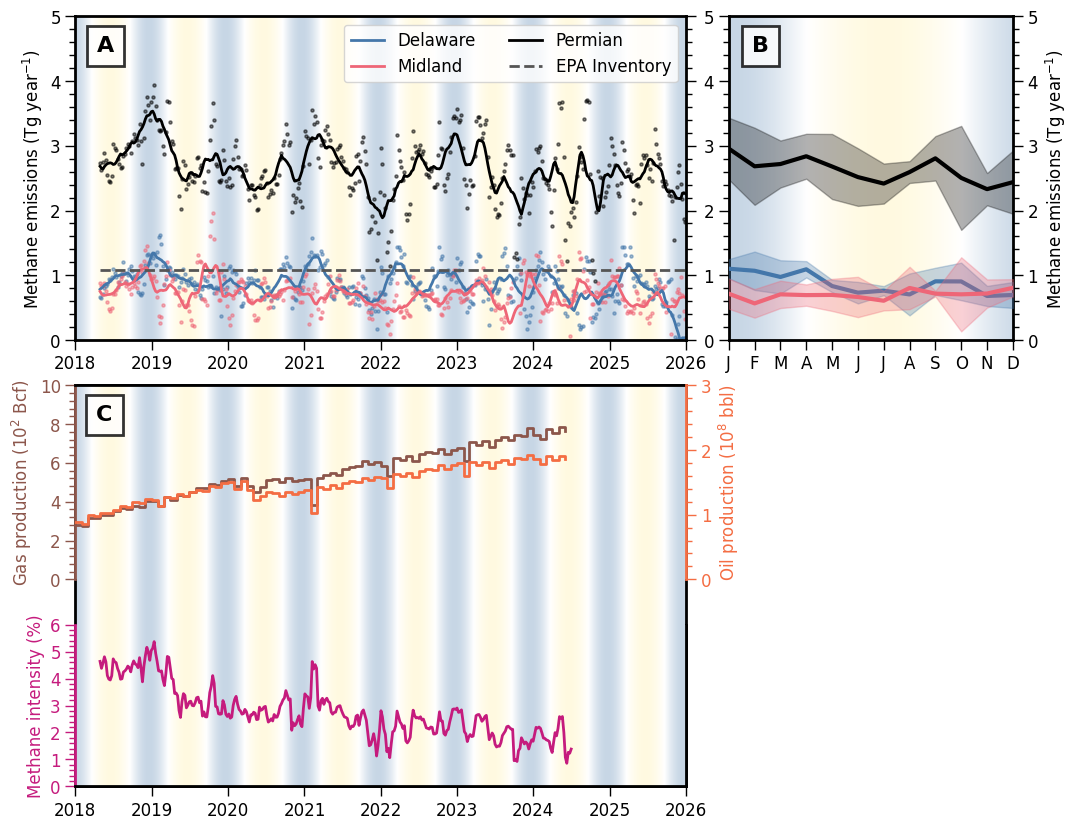

In [21]:
# Colors and parameters
color_schemes = {
    'oil_prod': '#f46d43',
    'gas_prod': '#8c564b',
    'intensity': '#c51b7d',
}


fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(3, 3, figure=fig, width_ratios=[2, 2, 2], height_ratios=[1, 0.6, 0.5], hspace=0.2, wspace=0.15)

plt.subplots_adjust(hspace=0) 


plt.subplots_adjust(right=0.75) 

ax_bg = fig.add_subplot(gs[1:, :2], zorder=-1)

ax_bg.tick_params(axis='y', which='both',
                     labelleft=False, labelright=False, colors="k", length=0)
ax_bg.tick_params(axis='x', which='both',
                     labeltop=False, labelbottom=False, colors="k", length=0)
ax_bg.spines['left'].set_linewidth(2)
ax_bg.spines['top'].set_linewidth(2)
ax_bg.spines['right'].set_linewidth(2)
ax_bg.spines['bottom'].set_linewidth(2)
# Emissions

ax = fig.add_subplot(gs[0, :2])
ax22 = fig.add_subplot(gs[0, 2]) # Seasonal cycle
ax_seasonal = ax22.twinx()

ax22.tick_params(axis='y', which='both',
                     labelleft=False, labelright=False, colors="blue", length=0)
ax_seasonal.tick_params(axis='y', which='both', left=False, right=True, 
                     labelleft=True, labelright=True, colors="k", labelsize=12)
ax_seasonal.tick_params(axis='y', which='major', left=True, right=True, 
                     labelleft=True, labelright=True, colors="k", labelsize=12, length=7, width=1)
ax_seasonal.tick_params(axis='y', which='minor', left=True, right=True, 
                     labelleft=True, labelright=True, colors="k", labelsize=12, length=4, width=1)

ax_seasonal.spines['left'].set_linewidth(2)
ax_seasonal.spines['top'].set_linewidth(2)
ax_seasonal.spines['bottom'].set_linewidth(2)
ax_seasonal.spines['right'].set_linewidth(2)

ax.tick_params(axis='y', which='both', left=True, right=True, 
                     labelleft=True, labelright=True, colors="k", labelsize=12)
ax.tick_params(axis='y', which='major', left=True, right=True, 
                     labelleft=True, labelright=False, colors="k", labelsize=12, length=7, width=1)
ax.tick_params(axis='y', which='minor', left=True, right=True, 
                     labelleft=True, labelright=False, colors="k", labelsize=12, length=4, width=1)
ax.spines["right"].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)
ax.spines['left'].set_linewidth(2)
ax.spines['top'].set_linewidth(2)
ax.tick_params(axis='x', which='both', bottom=True, top=False, labelbottom=True, labeltop=False, length=7, width=1, labelsize=12)

d_weekly_ems_df = pd.DataFrame(d_weekly_ems, index=d_timestamps, columns=["ems"])
d_weekly_ems_df["month"] = [val.month for val in d_weekly_ems_df.index]
d_weekly_ems_df["year"] = [val.year for val in d_weekly_ems_df.index]

ax.scatter(d_timestamps, d_weekly_ems, s=5, alpha=0.5, color="#4477AA")
ax.plot(d_timestamps, d_weekly_ems_df.rolling(window="84D", center=True)["ems"].mean(), color="#4477AA", linewidth=2, label="Delaware")

d_weekly_ems_df = d_weekly_ems_df[d_weekly_ems_df["year"]<2025].reset_index(drop=True)
month_ems = np.zeros((12, 6))

grouped = d_weekly_ems_df.groupby(["month", "year"])
for tstamp, data in grouped:
    row, col = tstamp
    val = data["ems"].mean()
    month_ems[row-1][col-2019] = val
# for idx in range(month_ems.shape[0]):
#     month_ems[idx] = fill_nan_1d(month_ems[idx])
mean = np.average(month_ems, axis=1)
std = np.std(month_ems, axis=1)
x = np.arange(month_ems.shape[0])
ax_seasonal.fill_between(x, mean-std, mean+std, alpha=0.3, color="#4477AA", zorder=50)
ax_seasonal.plot(np.average(month_ems, axis=1), linewidth=3, color="#4477AA", label="Delaware", zorder=50)

colors = ["#4477AA", "#FFFFFF", "#FFEE99"] # Blue to White to Yellow
n_bins = 100 
cmap_name = "blue_yellow_gradient"
custom_cmap = mcolors.LinearSegmentedColormap.from_list(cmap_name, colors, N=n_bins)

num_days = (datetime.datetime(2026, 1, 1) - datetime.datetime(2018, 1, 1)).days
days = np.arange(num_days)

seasonal_cycle = 0.5 * (1 + np.sin(2 * np.pi * (days - 80) / 365.25))

gradient = seasonal_cycle.reshape(1, -1)
extent = [mdates.date2num(datetime.datetime(2018, 1, 1)), 
          mdates.date2num(datetime.datetime(2026, 1, 1)), 
          -0.5, 100] # Matching your axs.set_ylim([500, 2100])

ax.imshow(gradient, aspect='auto', cmap=custom_cmap, extent=extent, alpha=0.3, zorder=0)


m_weekly_ems_df = pd.DataFrame(m_weekly_ems, index=m_timestamps, columns=["ems"])
m_weekly_ems_df["month"] = [val.month for val in m_weekly_ems_df.index]
m_weekly_ems_df["year"] = [val.year for val in m_weekly_ems_df.index]

ax.scatter(m_timestamps, m_weekly_ems, s=5, alpha=0.5, color="#EE6677")
ax.plot(m_timestamps, m_weekly_ems_df.rolling(window="84D", center=True)["ems"].mean(), color="#EE6677", linewidth=2, label="Midland")

month_ems = np.zeros((12, 6))
m_weekly_ems_df = m_weekly_ems_df[m_weekly_ems_df["year"]<2025].reset_index(drop=True)
grouped = m_weekly_ems_df.groupby(["month", "year"])
for tstamp, data in grouped:
    row, col = tstamp
    val = data["ems"].mean()
    month_ems[row-1][col-2019] = val
# for idx in range(month_ems.shape[0]):
#     month_ems[idx] = fill_nan_1d(month_ems[idx])
mean = np.average(month_ems, axis=1)
std = np.std(month_ems, axis=1)
x = np.arange(month_ems.shape[0])
ax_seasonal.fill_between(x, mean-std, mean+std, alpha=0.3, color="#EE6677", zorder=50)
ax_seasonal.plot(np.average(month_ems, axis=1), linewidth=3, color="#EE6677", label="Midland", zorder=50)


ax.scatter(total_ems_df.index, total, s=5, alpha=0.5, color="#000000")
ax.plot(total_ems_df.index, total_ems_df.rolling(window="84D", center=True).mean(), color="#000000", linewidth=2, label="Permian")
ax.plot(total_ems_df.index, prior_ems_df.rolling(window="84D", center=True).mean(), "--", color="#555555", linewidth=2, label="EPA Inventory")

comb_weekly_ems_df = pd.DataFrame(total, index=comb_timestamps, columns=["ems"])
comb_weekly_ems_df["month"] = [val.month for val in comb_weekly_ems_df.index]
comb_weekly_ems_df["year"] = [val.year for val in comb_weekly_ems_df.index]
month_ems = np.zeros((12, 6))

comb_weekly_ems_df = comb_weekly_ems_df[comb_weekly_ems_df["year"]<2025].reset_index(drop=True)
grouped = comb_weekly_ems_df.groupby(["month", "year"])
for tstamp, data in grouped:
    row, col = tstamp
    val = data["ems"].mean()
    month_ems[row-1][col-2019] = val

mean = np.average(month_ems, axis=1)
std = np.std(month_ems, axis=1)
x = np.arange(month_ems.shape[0])
ax_seasonal.fill_between(x, mean-std, mean+std, alpha=0.3, color="#000000", zorder=1)
ax_seasonal.plot(np.average(month_ems, axis=1), linewidth=3, color="#000000", label="Permian", zorder=10)

ax_seasonal.set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11])
ax_seasonal.set_xticklabels(["J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"])

for a in [ax22, ax_seasonal]:
    a.tick_params(axis='x', which='major', 
                   bottom=True, top=False, 
                   labelbottom=True, labeltop=False, 
                   length=7, width=1, direction='out', labelsize=12)
ax_seasonal.set_yticks(np.arange(0, 5.01, 0.5))
ax_seasonal.set_ylim([0, 5])

ax.set_yticks(np.arange(0, 5.01, 0.5))
ax.set_ylim([0, 5])

ax.legend(loc="upper right", fontsize=12, ncol=2)

ax.set_ylabel("Methane emissions (Tg year$^{-1}$)", fontsize=12)
ax_seasonal.set_ylabel("Methane emissions (Tg year$^{-1}$)", fontsize=12)
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax_seasonal.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax_seasonal.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.yaxis.grid(False)

bbox_props = dict(boxstyle="square,pad=0.45", ec="black", lw=2, facecolor='white', alpha=0.8)
ax.text(0.035, 0.94, "A", transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)

x_grad = np.linspace(0, 11, 1000)


# Production
ax = fig.add_subplot(gs[1, :2])

ax.imshow(gradient, aspect='auto', cmap=custom_cmap, extent=extent, alpha=0.3, zorder=0)

r_ax_oil = ax.twinx()
r_ax_oil.spines['bottom'].set_visible(False)
r_ax_oil.spines['top'].set_visible(False)
r_ax_oil.spines['right'].set_linewidth(2)
r_ax_oil.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
r_ax_oil.tick_params(axis='y', which='both', left=False, right=True, 
                     labelleft=False, labelright=True, colors=color_schemes['oil_prod'], labelsize=12)
r_ax_oil.tick_params(axis='y', which='major', right=True, length=7, width=1, colors=color_schemes['oil_prod'])
r_ax_oil.tick_params(axis='y', which='minor', right=True, length=4, width=1, colors=color_schemes['oil_prod'])
r_ax_oil.spines['left'].set_visible(False)
r_ax_oil.step(df["Month"], df["total_oil_bbl"]/1e8, where='post', color=color_schemes['oil_prod'], alpha=1, linewidth=2)
r_ax_oil.tick_params(axis='y', colors=color_schemes['oil_prod'])
r_ax_oil.spines['right'].set_color(color_schemes['oil_prod'])
r_ax_oil.set_ylabel('Oil production (10$^8$ bbl)', color=color_schemes['oil_prod'], fontsize=12)
r_ax_oil.yaxis.set_major_locator(ticker.MultipleLocator(1))
r_ax_oil.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))
r_ax_oil.set_ylim([0, 3])

r_ax_gas = ax

r_ax_gas.tick_params(axis='y', which='both', left=True, right=False, 
                     labelleft=True, labelright=False, colors=color_schemes['gas_prod'], labelsize=12)
r_ax_gas.tick_params(axis='y', which='major', length=7, width=1, labelright=False, colors=color_schemes['gas_prod'])
r_ax_gas.tick_params(axis='y', which='minor', length=4, width=1, labelright=False, colors=color_schemes['gas_prod'])
r_ax_gas.spines['left'].set_color(color_schemes['gas_prod'])
r_ax_gas.set_ylabel('Gas production (10$^2$ Bcf)', color=color_schemes['gas_prod'], fontsize=12)
r_ax_gas.yaxis.set_major_locator(ticker.MultipleLocator(2))
r_ax_gas.yaxis.set_minor_locator(ticker.MultipleLocator(0.4))
r_ax_gas.step(df["Month"], df["total_gas_bcf"]/1e2, where='post', color=color_schemes['gas_prod'], alpha=1, linewidth=2, zorder=5)
r_ax_gas.set_ylim([0, 10])
r_ax_gas.spines['bottom'].set_visible(False)
r_ax_gas.spines['top'].set_linewidth(2)
r_ax_gas.spines['right'].set_visible(False)
r_ax_gas.spines['left'].set_linewidth(2)
r_ax_gas.tick_params(axis='x', which='both', bottom=False, labelbottom=False)

ax.text(0.034, 0.9, "C", transform=ax.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)

# Methane intensity
ax = fig.add_subplot(gs[2, :2])
ax.spines['right'].set_linewidth(2)
ax.spines['top'].set_visible(False)
ax.spines['left'].set_linewidth(2)
ax.spines['bottom'].set_linewidth(2)

ax.tick_params(axis='y', which='both', left=True, right=False, 
                     labelleft=True, labelright=False, labelsize=12, colors=color_schemes["intensity"])
ax.tick_params(axis='y', which='major', left=True, right=False, 
                     labelleft=True, labelright=False, labelsize=12, length=7, width=1, colors=color_schemes["intensity"])
ax.tick_params(axis='y', which='minor', left=True, right=False, 
                     labelleft=True, labelright=False, labelsize=12, length=4, width=1, colors=color_schemes["intensity"])
ax.spines['left'].set_color(color_schemes['intensity'])
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_minor_locator(ticker.MultipleLocator(0.2))
ax.set_ylabel('Methane intensity (%)', color=color_schemes['intensity'], fontsize=12)

ax.plot([val[0] for val in intensity_data], [val[1] for val in intensity_data], linewidth=2, color=color_schemes["intensity"])
ax.set_ylim([0, 6])

ax.tick_params(axis='x', which='both', top=False, labelbottom=True, bottom=True, labeltop=False, length=7, width=1, labelsize=12)
ax.imshow(gradient, aspect='auto', cmap=custom_cmap, extent=extent, alpha=0.3, zorder=0)


ax_bg.imshow(gradient, aspect='auto', cmap=custom_cmap, extent=extent, alpha=0.3, zorder=0)


grad_values = 0.5 * (1 + np.sin(2 * np.pi * (x_grad / 12) - np.pi/2))


gradient = grad_values.reshape(1, -1)

ymin, ymax = -1, 11
ax_seasonal.imshow(gradient, aspect='auto', cmap=custom_cmap, 
           extent=[0, 11, ymin, ymax], alpha=0.3, zorder=0)
ax_seasonal.text(0.08, 0.94, "B", transform=ax_seasonal.transAxes,
            fontsize=16, fontweight='bold', va='top', ha='left', bbox=bbox_props)

plt.show()

# Gridcell-Level Flux Changes (Inversion Results)

In [ ]:
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

# Find and load latest inversion file
inversion_files = sorted(glob.glob('data/inversions/inversion_data_*.nc'))
if inversion_files:
    inversion_file = inversion_files[-1]
    print(f'Loading: {inversion_file}')
    ds = nc.Dataset(inversion_file, 'r')
    
    prior_fluxes = ds.variables['prior_fluxes'][:]
    post_fluxes = ds.variables['post_fluxes'][:]
    dates = ds.variables['date'][:]
    
    print(f'Prior shape: {prior_fluxes.shape}')
    print(f'Posterior shape: {post_fluxes.shape}')
    print(f'Number of weeks: {len(dates)}')
    print(f'Dates: {[int(d) for d in dates]}')
else:
    print('No inversion files found!')

In [ ]:
# Prior emissions heatmap
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(prior_fluxes, origin='lower', cmap='viridis', interpolation='nearest')
ax.set_xlabel('Longitude grid cell')
ax.set_ylabel('Latitude grid cell')
ax.set_title('Prior Emissions (EPA Inventory)')
cbar = plt.colorbar(im, ax=ax)
cbar.set_label('Flux (umol/m²/s)')
plt.tight_layout()
plt.show()

In [ ]:
# Posterior emissions for each week
n_weeks = post_fluxes.shape[0]
n_cols = 3
n_rows = (n_weeks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
if n_weeks == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for week_idx in range(n_weeks):
    ax = axes[week_idx]
    im = ax.imshow(post_fluxes[week_idx], origin='lower', cmap='viridis', interpolation='nearest')
    ax.set_xlabel('Longitude grid cell')
    ax.set_ylabel('Latitude grid cell')
    ax.set_title(f'Posterior Emissions - Week {week_idx} (Date {int(dates[week_idx])})')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Flux (umol/m²/s)')

# Hide unused subplots
for ax in axes[n_weeks:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# Flux changes (posterior - prior) for each week
# Use symmetric colormap centered at zero
n_weeks = post_fluxes.shape[0]
n_cols = 3
n_rows = (n_weeks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
if n_weeks == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for week_idx in range(n_weeks):
    ax = axes[week_idx]
    change = post_fluxes[week_idx] - prior_fluxes
    
    # Symmetric colormap centered at 0
    vmax = np.max(np.abs(change))
    im = ax.imshow(change, origin='lower', cmap='RdBu_r', 
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_xlabel('Longitude grid cell')
    ax.set_ylabel('Latitude grid cell')
    ax.set_title(f'Flux Change - Week {week_idx} (Date {int(dates[week_idx])})\nPosterior - Prior')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Δ Flux (umol/m²/s)')

# Hide unused subplots
for ax in axes[n_weeks:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

# Print statistics
print('\nFlux Change Statistics by Week:')
for week_idx in range(n_weeks):
    change = post_fluxes[week_idx] - prior_fluxes
    print(f'  Week {week_idx} (date {int(dates[week_idx])}):')
    print(f'    Min: {np.min(change):+.4e} umol/m²/s')
    print(f'    Mean: {np.mean(change):+.4e} umol/m²/s')
    print(f'    Max: {np.max(change):+.4e} umol/m²/s')
    print(f'    % cells with positive change: {100*np.sum(change > 0)/change.size:.1f}%')

In [ ]:
# Week-to-week changes
if n_weeks > 1:
    n_deltas = n_weeks - 1
    n_cols = 3
    n_rows = (n_deltas + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
    if n_deltas == 1:
        axes = [axes]
    else:
        axes = axes.flatten()
    
    for week_idx in range(n_weeks - 1):
        ax = axes[week_idx]
        delta = post_fluxes[week_idx + 1] - post_fluxes[week_idx]
        
        # Symmetric colormap centered at 0
        vmax = np.max(np.abs(delta))
        if vmax > 0:
            im = ax.imshow(delta, origin='lower', cmap='RdBu_r', 
                           vmin=-vmax, vmax=vmax, interpolation='nearest')
        else:
            im = ax.imshow(delta, origin='lower', cmap='Greys', interpolation='nearest')
        
        ax.set_xlabel('Longitude grid cell')
        ax.set_ylabel('Latitude grid cell')
        ax.set_title(f'Week {week_idx} → {week_idx+1} Change\n(Date {int(dates[week_idx])} → {int(dates[week_idx+1])})')
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label('Δ Flux (umol/m²/s)')
    
    # Hide unused subplots
    for ax in axes[n_deltas:]:
        ax.set_visible(False)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print('\nWeek-to-Week Change Statistics:')
    for week_idx in range(n_weeks - 1):
        delta = post_fluxes[week_idx + 1] - post_fluxes[week_idx]
        print(f'  Week {week_idx} → {week_idx+1}:')
        print(f'    Min: {np.min(delta):+.4e} umol/m²/s')
        print(f'    Mean: {np.mean(delta):+.4e} umol/m²/s')
        print(f'    Max: {np.max(delta):+.4e} umol/m²/s')
else:
    print('Only 1 week in inversion, cannot compute week-to-week changes.')

In [ ]:
# Observation domain (inner 40×40) zoomed view
obs_margin = 100  # from config
obs_end = 240 - obs_margin  # 140
obs_domain_slice = slice(obs_margin, obs_end)

n_weeks = post_fluxes.shape[0]
n_cols = 3
n_rows = (n_weeks + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5*n_rows))
if n_weeks == 1:
    axes = [axes]
else:
    axes = axes.flatten()

for week_idx in range(n_weeks):
    ax = axes[week_idx]
    change = post_fluxes[week_idx, obs_domain_slice, obs_domain_slice] - prior_fluxes[obs_domain_slice, obs_domain_slice]
    
    # Symmetric colormap
    vmax = np.max(np.abs(change))
    im = ax.imshow(change, origin='lower', cmap='RdBu_r', 
                   vmin=-vmax, vmax=vmax, interpolation='nearest')
    ax.set_xlabel('Longitude grid cell')
    ax.set_ylabel('Latitude grid cell')
    ax.set_title(f'OBSERVATION DOMAIN ONLY - Week {week_idx}\n(Date {int(dates[week_idx])})')
    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label('Δ Flux (umol/m²/s)')

# Hide unused subplots
for ax in axes[n_weeks:]:
    ax.set_visible(False)

plt.tight_layout()
plt.show()

print(f'\nObservation Domain: rows {obs_margin}:{obs_end}, cols {obs_margin}:{obs_end} (40×40 grid)')
print('\nObservation Domain Flux Change Statistics:')
for week_idx in range(n_weeks):
    change = post_fluxes[week_idx, obs_domain_slice, obs_domain_slice] - prior_fluxes[obs_domain_slice, obs_domain_slice]
    print(f'  Week {week_idx} (date {int(dates[week_idx])}):')
    print(f'    Min: {np.min(change):+.4e} umol/m²/s')
    print(f'    Mean: {np.mean(change):+.4e} umol/m²/s')
    print(f'    Max: {np.max(change):+.4e} umol/m²/s')
    print(f'    Total domain change: {np.sum(change):+.4e} umol/m²/s')